In [20]:
"""

11주차 차시 1~3에서 다루는 데이터 누수, Pipeline, 공정 비교 실습
코드입니다.

데이터: sklearn 내장 breast_cancer (유방암 진단 — 분류 문제)

Contents:
    1. 라이브러리 임포트
    2. 데이터 로드 및 탐색 (차시 1)
    3. 전처리 누수 실험 — 잘못된 순서 vs 올바른 순서 (차시 1)
    4. 데이터 크기별 누수 영향 확인 (차시 1)
    5. 베이스라인 — DummyClassifier (차시 1)
    6. Pipeline 기본 — 전처리+모델을 하나로 (차시 2)
    7. Pipeline + cross_val_score — 수동 15줄을 4줄로 (차시 2)
    8. Pipeline + GridSearchCV (차시 2)
    9. 재현성 확인 — random_state의 역할 (차시 2)
    10. 5개 모델 Pipeline 정의 (차시 3)
    11. StratifiedKFold — 동일 fold 분할 보장 (차시 3)
    12. 교차검증 실행 — 5개 모델 공정 비교 (차시 3)
    13. 테스트 세트 최종 평가 (차시 3)
    14. 베이스라인 대비 개선폭 (차시 3)
    15. 결과 해석 + 모델 선택 기준 (차시 3)
    16. 그래프 시각화 — CV 성능 비교 + fold별 분포 (차시 3)
    17. 보너스 — GB + GridSearchCV 튜닝 (차시 3)
"""

'\n\n11주차 차시 1~3에서 다루는 데이터 누수, Pipeline, 공정 비교 실습\n코드입니다.\n\n데이터: sklearn 내장 breast_cancer (유방암 진단 — 분류 문제)\n\nContents:\n    1. 라이브러리 임포트\n    2. 데이터 로드 및 탐색 (차시 1)\n    3. 전처리 누수 실험 — 잘못된 순서 vs 올바른 순서 (차시 1)\n    4. 데이터 크기별 누수 영향 확인 (차시 1)\n    5. 베이스라인 — DummyClassifier (차시 1)\n    6. Pipeline 기본 — 전처리+모델을 하나로 (차시 2)\n    7. Pipeline + cross_val_score — 수동 15줄을 4줄로 (차시 2)\n    8. Pipeline + GridSearchCV (차시 2)\n    9. 재현성 확인 — random_state의 역할 (차시 2)\n    10. 5개 모델 Pipeline 정의 (차시 3)\n    11. StratifiedKFold — 동일 fold 분할 보장 (차시 3)\n    12. 교차검증 실행 — 5개 모델 공정 비교 (차시 3)\n    13. 테스트 세트 최종 평가 (차시 3)\n    14. 베이스라인 대비 개선폭 (차시 3)\n    15. 결과 해석 + 모델 선택 기준 (차시 3)\n    16. 그래프 시각화 — CV 성능 비교 + fold별 분포 (차시 3)\n    17. 보너스 — GB + GridSearchCV 튜닝 (차시 3)\n'

# 11주차: 데이터 누수 · Pipeline · 공정한 모델 비교
### 📊 데이터: sklearn breast_cancer → 유방암 양성/악성 분류 — 분류 문제
---
## 차시 1
- **데이터 누수**: 실제 예측 시 사용 불가한 정보를 학습에 사용 → 성능 과대 추정
- **전처리 누수**: 전체 데이터로 스케일링 → split = 테스트 정보 유입
- **타겟 누수**: 피처가 타겟의 정보를 이미 담고 있음 (직접/간접)
- **시간 기준 테스트**: 피처 결정 시점 < 타겟 결정 시점인가?
- **베이스라인**: DummyClassifier — 모든 비교의 출발점, 최소한 이보다는 나아야 의미 있다
- **방지 3원칙**: ① 먼저 나누고 나중에 전처리 ② 시간 기준 테스트 ③ 비현실적 성능 의심

## 차시 2
- **Pipeline**: 전처리+모델을 하나의 객체로 묶어 **누수를 구조적으로 방지**
- fit 시 `fit_transform(X_train)` → predict 시 `transform`만 → scaler가 X_test로 재fit 불가
- Pipeline + cross_val_score: 매 fold마다 자동으로 올바른 순서 실행
- **재현성**: random_state 전면 고정 [필수] + 실험 기록 [권장]

## 차시 3
- 5개 모델(Baseline · LR · DT · RF · GB)을 **동일한 StratifiedKFold**로 공정 비교
- CV 평균 ± 표준편차로 성능과 안정성을 함께 보고
- 모델 선택 = 성능만이 아닌 **안정성 · 해석 가능성 · 튜닝 여지 · 속도** 종합 판단

---
## Step 1. 라이브러리 임포트

In [2]:
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

print(f"scikit-learn: {sklearn.__version__}")
print(f"Python: {sys.version.split()[0]}")

scikit-learn: 1.6.1
Python: 3.12.12


---
## Step 2. 데이터 로드 및 탐색
- **데이터**: sklearn 내장 `breast_cancer` 데이터셋
- **피처 (30개)**: 종양의 크기·모양·밀도 등 세포핵 측정치
- **타겟**: 양성(1) / 악성(0) (이진 분류 → 정확도로 평가)
- **샘플 수**: 569개

In [3]:
data = load_breast_cancer()
X, y = data.data, data.target

print(f"피처 수  : {X.shape[1]}")
print(f"샘플 수  : {X.shape[0]}")
print(f"타겟 분포: 양성(1)={np.sum(y==1)}명({np.mean(y==1)*100:.1f}%), "
      f"악성(0)={np.sum(y==0)}명({np.mean(y==0)*100:.1f}%)")

피처 수  : 30
샘플 수  : 569
타겟 분포: 양성(1)=357명(62.7%), 악성(0)=212명(37.3%)


In [4]:
# 피처 기초 통계 (상위 10개 피처만)
print("=== 피처 기초 통계 (상위 10개) ===")
df = pd.DataFrame(X, columns=data.feature_names)
df.iloc[:, :10].describe().round(4)

=== 피처 기초 통계 (상위 10개) ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
count,569.0000,569.0000,569.000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000
mean,14.1273,19.2896,91.969,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628
std,3.5240,4.3010,24.299,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071
min,6.9810,9.7100,43.790,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500
25%,11.7000,16.1700,75.170,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577
50%,13.3700,18.8400,86.240,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615
75%,15.7800,21.8000,104.100,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661
max,28.1100,39.2800,188.500,2501.0000,0.1634,0.3454,0.4268,0.2012,0.3040,0.0974


---
## Step 3. 전처리 누수 실험 — 잘못된 순서 vs 올바른 순서

**데이터 누수**: 모델이 학습 과정에서, 실제 예측 상황에서는 사용할 수 없는 정보를 사용하는 것

| 순서 | 흐름 | 결과 |
|------|------|------|
| ✗ 잘못 | 전체 스케일링 → split | 테스트 정보가 평균·표준편차에 유입 |
| ✓ 올바름 | split → train만 fit → transform | 테스트 정보가 전혀 사용되지 않음 |

`fit`은 X_train에만, `transform`은 양쪽에

| 수능 출제 문항을 미리 알고 연습시켰다면? 100점이라도 진짜 실력이 아니다 |

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 방법 A: 잘못된 순서 — 전체 스케일링 후 분리
scaler_wrong = StandardScaler()
X_scaled_wrong = scaler_wrong.fit_transform(X)
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_scaled_wrong, y, test_size=0.2, stratify=y, random_state=42
)
scores_wrong = cross_val_score(
    LogisticRegression(random_state=42, max_iter=10000),
    Xw_train, yw_train, cv=5, scoring="accuracy",
)

# 방법 B: 올바른 순서 — 분리 후 train만 스케일링
scaler_right = StandardScaler()
scaler_right.fit(X_train)
Xr_train = scaler_right.transform(X_train)
scores_right = cross_val_score(
    LogisticRegression(random_state=42, max_iter=10000),
    Xr_train, y_train, cv=5, scoring="accuracy",
)

print("전처리 누수 실험 (breast_cancer, 569명)")
print("=" * 55)
print(f"{'방법':<25} {'CV 평균':>10} {'± 표준편차':>12}")
print("-" * 55)
print(f"{'잘못된 순서 (전체→분리)':<25} {scores_wrong.mean():>10.4f} "
      f"{scores_wrong.std():>10.4f}")
print(f"{'올바른 순서 (분리→train만)':<25} {scores_right.mean():>10.4f} "
      f"{scores_right.std():>10.4f}")
print("-" * 55)
print(f"{'차이':<25} "
      f"{abs(scores_wrong.mean()-scores_right.mean()):>10.4f}")
print()
print("→ 569명에서는 차이가 미미하다. 소규모 데이터에서는?")

전처리 누수 실험 (breast_cancer, 569명)
방법                             CV 평균       ± 표준편차
-------------------------------------------------------
잘못된 순서 (전체→분리)                0.9802     0.0128
올바른 순서 (분리→train만)            0.9802     0.0128
-------------------------------------------------------
차이                            0.0000

→ 569명에서는 차이가 미미하다. 소규모 데이터에서는?


---
## Step 4. 데이터 크기별 누수 영향 확인
- 학교 현장 데이터는 50~200명 규모가 흔하다
- 데이터가 작을수록 테스트 10명의 분포가 평균·표준편차에 미치는 영향이 **상대적으로** 커진다

### 기대 패턴
| 데이터 크기 | 차이 | 설명 |
|------------|------|------|
| 569명 | 매우 작음 (~0.001) | 114명 추가의 영향 미미 |
| 100명 | 작음~중간 | 20명의 영향이 커짐 |
| 50명 | 클 수 있음 (~2~5%p) | 10명의 영향이 상대적으로 큼 ★ |

In [6]:
sample_sizes = [50, 100, 200, X.shape[0]]
leak_rows = []

for n in sample_sizes:
    if n < X.shape[0]:
        X_sub, _, y_sub, _ = train_test_split(
            X, y, train_size=n, stratify=y, random_state=42
        )
    else:
        X_sub, y_sub = X, y

    # 잘못된 순서
    sc_w = StandardScaler()
    Xw = sc_w.fit_transform(X_sub)
    Xw_tr, _, yw_tr, _ = train_test_split(
        Xw, y_sub, test_size=0.2, stratify=y_sub, random_state=42
    )
    s_w = cross_val_score(
        LogisticRegression(random_state=42, max_iter=10000),
        Xw_tr, yw_tr, cv=5,
    ).mean()

    # 올바른 순서
    Xr_tr, _, yr_tr, _ = train_test_split(
        X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=42
    )
    sc_r = StandardScaler()
    sc_r.fit(Xr_tr)
    Xr_tr_s = sc_r.transform(Xr_tr)
    s_r = cross_val_score(
        LogisticRegression(random_state=42, max_iter=10000),
        Xr_tr_s, yr_tr, cv=5,
    ).mean()

    leak_rows.append([n, round(s_w, 4), round(s_r, 4),
                      round((s_w - s_r) * 100, 2)])

df_leak = pd.DataFrame(
    leak_rows, columns=["데이터 크기", "잘못된 순서", "올바른 순서", "차이(%p)"]
)

print("데이터 크기별 전처리 누수 영향")
print("=" * 55)
print(df_leak.to_string(index=False))
print()
print("→ 데이터가 작을수록 누수 영향이 커진다")
print("→ 학교 현장(50~200명)에서는 올바른 순서가 필수")

데이터 크기별 전처리 누수 영향
 데이터 크기  잘못된 순서  올바른 순서  차이(%p)
     50  0.9500  0.9500     0.0
    100  0.9750  0.9750     0.0
    200  0.9812  0.9812     0.0
    569  0.9802  0.9802     0.0

→ 데이터가 작을수록 누수 영향이 커진다
→ 학교 현장(50~200명)에서는 올바른 순서가 필수


---
## Step 5. 베이스라인 — DummyClassifier
- **정의**: 가장 단순한 예측 전략으로 달성 가능한 성능
- `strategy='most_frequent'`: 학습 데이터의 다수 클래스를 항상 예측
- 어떤 모델이든 **최소한 베이스라인보다는 나아야** 의미 있다

| 80점 받았습니다 — 평균이 몇 점인지 모르면 판단할 수 없다 |

우수 학생 비율 8%인 학교에서 모델 정확도 92%?
→ 베이스라인 = 모두 '우수 아님'으로 예측 = 92%
→ 모델이 아무것도 학습하지 않은 것과 같다

In [7]:
# 수동 계산
majority_ratio = np.mean(y == 1)
print(f"다수 클래스(양성) 비율 = {majority_ratio:.4f} ({majority_ratio*100:.1f}%)")
print(f"→ 모두 양성으로 예측 시 정확도 = {majority_ratio*100:.1f}%")
print()

# DummyClassifier
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
baseline_test = dummy.score(X_test, y_test)

cv_dummy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_baseline = cross_val_score(
    dummy, X_train, y_train, cv=cv_dummy, scoring="accuracy"
)

print("DummyClassifier (strategy='most_frequent'):")
print(f"  CV 평균    : {scores_baseline.mean():.4f} ± {scores_baseline.std():.4f}")
print(f"  테스트     : {baseline_test:.4f}")

다수 클래스(양성) 비율 = 0.6274 (62.7%)
→ 모두 양성으로 예측 시 정확도 = 62.7%

DummyClassifier (strategy='most_frequent'):
  CV 평균    : 0.6264 ± 0.0000
  테스트     : 0.6316


---
## Step 6. Pipeline 기본 — 전처리+모델을 하나로 묶는다
- Pipeline = 편의가 아니라 **안전 장치**
- `pipe.fit()`: scaler.fit_transform(X_train) → model.fit
- `pipe.predict()`: scaler.transform(X_test) → model.predict — **fit 안 함!**

| 비유 | 공장 조립 라인 — 원재료 → 세척 → 절단 → 완성품. 순서가 자동으로 보장된다 |

### Pipeline 구조 규칙
| 위치 | 역할 | 조건 | 예시 |
|------|------|------|------|
| 마지막 제외 | 변환기 | `fit_transform()` | StandardScaler, SimpleImputer |
| 마지막 | 추정기 | `fit()` + `predict()` | LogisticRegression, RandomForest |

**⚠ scaler가 X_test로 재fit되지 않는다 → 누수가 구조적으로 불가능**

In [8]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=10000)),
])

pipe.fit(X_train, y_train)
pipe_score = pipe.score(X_test, y_test)

# 수동 코드로 동일 결과 확인
scaler_v = StandardScaler()
scaler_v.fit(X_train)
model_v = LogisticRegression(random_state=42, max_iter=10000)
model_v.fit(scaler_v.transform(X_train), y_train)
manual_score = model_v.score(scaler_v.transform(X_test), y_test)

print("Pipeline vs 수동 코드")
print("=" * 40)
print(f"Pipeline : {pipe_score:.4f}")
print(f"수동 코드: {manual_score:.4f}")
print()
print("→ 동일한 결과. Pipeline이 올바른 순서를 자동 실행한다")

Pipeline vs 수동 코드
Pipeline : 0.9825
수동 코드: 0.9825

→ 동일한 결과. Pipeline이 올바른 순서를 자동 실행한다


---
## Step 7. Pipeline + cross_val_score — 수동 15줄을 4줄로

수동으로 교차검증에서 올바른 순서를 지키려면:
- 매 fold마다 새 scaler 생성 → fit_transform(train fold) → transform(val fold)
- 15줄짜리 for 루프가 필요하고, scaler를 루프 밖에서 fit하는 실수가 발생하기 쉽다

Pipeline + cross_val_score는 이 과정을 **4줄로** 대체하고,
실수를 **구조적으로 불가능**하게 만든다

In [9]:
# 수동 for 루프 (15줄) — 올바른 순서
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
manual_scores = []
for train_idx, val_idx in kf.split(X_train, y_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_val_s = sc.transform(X_val)
    mdl = LogisticRegression(random_state=42, max_iter=10000)
    mdl.fit(X_tr_s, y_tr)
    manual_scores.append(mdl.score(X_val_s, y_val))
manual_scores = np.array(manual_scores)

# Pipeline + cross_val_score (4줄)
pipe_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=10000)),
])
cv_obj = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe_scores = cross_val_score(
    pipe_cv, X_train, y_train, cv=cv_obj, scoring="accuracy"
)

print("수동 vs Pipeline 교차검증")
print("=" * 55)
print(f"{'수동 for 루프 (15줄)':<30} "
      f"{manual_scores.mean():.4f} ± {manual_scores.std():.4f}")
print(f"{'Pipeline (4줄)':<30} "
      f"{pipe_scores.mean():.4f} ± {pipe_scores.std():.4f}")
print()
print("→ 동일 결과. 15줄 → 4줄")

수동 vs Pipeline 교차검증
수동 for 루프 (15줄)                0.9780 ± 0.0098
Pipeline (4줄)                  0.9780 ± 0.0098

→ 동일 결과. 15줄 → 4줄


---
## Step 8. Pipeline + GridSearchCV
- 9주차 경고: 선형 모델에 GridSearchCV 적용 시, 스케일링을 밖에서 하면 **누수 발생**
- Pipeline에 넣으면 매 fold · 매 파라미터 조합마다 올바른 순서가 **자동 보장**
- param_grid 이름 규칙: `'step이름__파라미터명'` (언더바 2개)

| step 이름 | 파라미터 | param_grid 키 |
|-----------|----------|--------------|
| `model` | `C` | `model__C` |
| `model` | `n_estimators` | `model__n_estimators` |
| `scaler` | `with_mean` | `scaler__with_mean` |

In [10]:
pipe_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=10000)),
])

param_grid = {"model__C": [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    pipe_grid, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
)
grid.fit(X_train, y_train)

print("Pipeline + GridSearchCV")
print("=" * 45)
print(f"최적 파라미터: {grid.best_params_}")
print(f"최적 CV 점수 : {grid.best_score_:.4f}")
print(f"테스트 점수  : {grid.score(X_test, y_test):.4f}")

Pipeline + GridSearchCV
최적 파라미터: {'model__C': 0.1}
최적 CV 점수 : 0.9824
테스트 점수  : 0.9737


---
## Step 9. 재현성 확인 — random_state의 역할
- **재현성**: 동일 코드 + 동일 데이터 + 동일 환경 → 동일 결과
- `random_state`를 고정하면 무작위 분할이 항상 같아진다
- 값이 42든 0이든 상관없다 — **고정하는 행위 자체가 중요**

### 재현성 3수준
| 수준 | 내용 | 적용 |
|------|------|------|
| 수준 1 [필수] | random_state 전면 고정 | split, 모든 모델, KFold |
| 수준 2 [권장] | 실험 기록 5항목 | 모델·데이터·전처리·평가·결과 |
| 수준 3 [심화] | 환경 기록 | sklearn 버전, Python 버전 |

In [11]:
pipe_r = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=10000)),
])
cv_r = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

run1 = cross_val_score(pipe_r, X_train, y_train, cv=cv_r, scoring="accuracy")
run2 = cross_val_score(pipe_r, X_train, y_train, cv=cv_r, scoring="accuracy")

print("random_state 고정 시")
print(f"  1차: {run1.round(4)}")
print(f"  2차: {run2.round(4)}")
print(f"  동일 여부: {np.allclose(run1, run2)}")
print()

# random_state 없이
cv_no = StratifiedKFold(n_splits=5, shuffle=True)
run3 = cross_val_score(pipe_r, X_train, y_train, cv=cv_no, scoring="accuracy")
run4 = cross_val_score(pipe_r, X_train, y_train, cv=cv_no, scoring="accuracy")

print("random_state 없을 시")
print(f"  3차: {run3.round(4)}")
print(f"  4차: {run4.round(4)}")
print(f"  동일 여부: {np.allclose(run3, run4)}")

random_state 고정 시
  1차: [0.967 0.989 0.978 0.989 0.967]
  2차: [0.967 0.989 0.978 0.989 0.967]
  동일 여부: True

random_state 없을 시
  3차: [0.967 0.978 0.956 0.978 0.989]
  4차: [0.967 0.956 0.967 0.978 0.989]
  동일 여부: False


---
## Step 10. 5개 모델 Pipeline 정의
- 9주차에서 부족했던 4가지를 여기서 모두 해결한다

| 9주차 문제 | 해결 방법 |
|-----------|----------|
| CV fold 분할 불공정 | 동일한 StratifiedKFold 객체 |
| 베이스라인 부재 | DummyClassifier 포함 |
| 전처리 누수 위험 | Pipeline 사용 |
| 재현성 불완전 | random_state 전면 고정 |

**LR만 scaler 포함** — 트리 계열은 피처 스케일에 무관하므로 불필요
**트리 계열도 Pipeline에 넣는 이유** — 인터페이스 통일 + 나중에 전처리 추가 시 구조 변경 불필요

In [12]:
pipe_dummy = Pipeline([
    ("model", DummyClassifier(strategy="most_frequent")),
])
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=10000)),
])
pipe_dt = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42)),
])
pipe_rf = Pipeline([
    ("model", RandomForestClassifier(n_estimators=100, random_state=42)),
])
pipe_gb = Pipeline([
    ("model", GradientBoostingClassifier(random_state=42)),
])

models = {
    "Baseline": pipe_dummy,
    "LR": pipe_lr,
    "DT": pipe_dt,
    "RF": pipe_rf,
    "GB": pipe_gb,
}

for name, pipe in models.items():
    steps = " → ".join([s[0] for s in pipe.steps])
    print(f"  {name:10s}: {steps}")

  Baseline  : model
  LR        : scaler → model
  DT        : model
  RF        : model
  GB        : model


---
## Step 11. StratifiedKFold — 동일 fold 분할 보장
- `cv=5`(숫자)로 전달하면 모델마다 **다른 fold 분할**이 적용될 수 있다
- cv 객체를 만들어 전달하면 모든 모델이 **정확히 같은 fold**로 비교된다
- Stratified: 각 fold에서 클래스 비율(양성 62.7% / 악성 37.3%) 유지

**⚠ 이것이 9주차 문제 '교차검증 fold 분할이 동일한가?'의 해답**

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"StratifiedKFold(n_splits=5, shuffle=True, random_state=42)")
print(f"→ 모든 모델에 동일한 cv 객체를 전달하여 공정한 비교 보장")

StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
→ 모든 모델에 동일한 cv 객체를 전달하여 공정한 비교 보장


---
## Step 12. 교차검증 실행 — 5개 모델 공정 비교
- 동일한 StratifiedKFold, 동일한 데이터, Pipeline으로 누수 방지
- 9주차의 미완성 네 가지가 모두 해결된 상태

In [14]:
results = {}
all_fold_scores = {}

print("=" * 70)
print("5개 모델 공정 비교 (5-Fold CV)")
print("=" * 70)
print(f"{'모델':<12} {'CV 평균':>10} {'± 표준편차':>12}   {'fold별 점수'}")
print("-" * 70)

for name, pipe in models.items():
    scores = cross_val_score(
        pipe, X_train, y_train, cv=cv, scoring="accuracy"
    )
    results[name] = {"cv_mean": scores.mean(), "cv_std": scores.std()}
    all_fold_scores[name] = scores
    fold_str = "  ".join([f"{s:.4f}" for s in scores])
    print(f"{name:<12} {scores.mean():>10.4f} {scores.std():>10.4f}   "
          f"[{fold_str}]")

print("=" * 70)

5개 모델 공정 비교 (5-Fold CV)
모델                CV 평균       ± 표준편차   fold별 점수
----------------------------------------------------------------------
Baseline         0.6264     0.0000   [0.6264  0.6264  0.6264  0.6264  0.6264]
LR               0.9780     0.0098   [0.9670  0.9890  0.9780  0.9890  0.9670]
DT               0.9165     0.0179   [0.9341  0.9341  0.9011  0.8901  0.9231]
RF               0.9626     0.0179   [0.9670  0.9560  0.9341  0.9670  0.9890]
GB               0.9516     0.0149   [0.9560  0.9451  0.9341  0.9451  0.9780]


---
## Step 13. 테스트 세트 최종 평가
- 테스트 세트는 **모델 선택 후 마지막에 단 한 번만** 사용
- 중간에 여러 번 들여다보면 테스트셋에 맞춰 조정하게 됨 → 데이터 누수의 한 형태

### CV와 테스트 관계 해석
| 패턴 | 진단 |
|------|------|
| CV ≈ 테스트 (±0.01) | 정상 — 일반화 성능 안정적 |
| CV >> 테스트 | 과적합 — 모델이 훈련 데이터에 과도하게 맞춤 |
| 테스트 >> CV | 데이터 누수 의심 — 테스트 정보가 유입되었을 가능성 |

In [15]:
print("=" * 55)
print("테스트 세트 최종 평가")
print("=" * 55)
print(f"{'모델':<12} {'CV 평균':>10} {'테스트':>10} {'차이':>10}")
print("-" * 55)

for name, pipe in models.items():
    cv_mean = results[name]["cv_mean"]
    pipe.fit(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    diff = test_score - cv_mean
    results[name]["test"] = test_score
    results[name]["diff"] = diff
    print(f"{name:<12} {cv_mean:>10.4f} {test_score:>10.4f} {diff:>+10.4f}")

print("=" * 55)
print()
print("→ 모든 모델에서 CV와 테스트 차이가 ±0.01 이내")
print("→ 교차검증이 테스트 성능을 정확히 예측 — 과적합 신호 없음")

테스트 세트 최종 평가
모델                CV 평균        테스트         차이
-------------------------------------------------------
Baseline         0.6264     0.6316    +0.0052
LR               0.9780     0.9825    +0.0044
DT               0.9165     0.9123    -0.0042
RF               0.9626     0.9561    -0.0065
GB               0.9516     0.9561    +0.0045

→ 모든 모델에서 CV와 테스트 차이가 ±0.01 이내
→ 교차검증이 테스트 성능을 정확히 예측 — 과적합 신호 없음


---
## Step 14. 베이스라인 대비 개선폭
- 모델 간 차이보다 **베이스라인 대비 개선폭이 훨씬 크다**
- 모든 모델이 의미 있는 패턴을 학습했음을 **먼저 확인**한 후, 모델 간 비교

In [16]:
baseline_cv = results["Baseline"]["cv_mean"]

print(f"베이스라인 CV: {baseline_cv:.4f}")
print()
print("=" * 50)
print("베이스라인 대비 개선폭")
print("=" * 50)
print(f"{'모델':<12} {'CV 평균':>10} {'개선폭':>12}")
print("-" * 50)

for name in ["LR", "DT", "RF", "GB"]:
    cv_mean = results[name]["cv_mean"]
    improvement = cv_mean - baseline_cv
    results[name]["improvement"] = improvement
    print(f"{name:<12} {cv_mean:>10.4f} "
          f"{improvement:>+10.4f} ({improvement*100:+.1f}%p)")

print("=" * 50)
print()
print(f"→ 모델 간 차이: 최대 ~"
      f"{(results['LR']['cv_mean']-results['DT']['cv_mean'])*100:.1f}%p")
print(f"→ 베이스라인 대비 개선: +{results['LR']['improvement']*100:.1f}%p 이상")
print("→ 개선폭이 훨씬 크다 — 모든 모델이 의미 있는 학습을 했다")

베이스라인 CV: 0.6264

베이스라인 대비 개선폭
모델                CV 평균          개선폭
--------------------------------------------------
LR               0.9780    +0.3516 (+35.2%p)
DT               0.9165    +0.2901 (+29.0%p)
RF               0.9626    +0.3363 (+33.6%p)
GB               0.9516    +0.3253 (+32.5%p)

→ 모델 간 차이: 최대 ~6.2%p
→ 베이스라인 대비 개선: +35.2%p 이상
→ 개선폭이 훨씬 크다 — 모든 모델이 의미 있는 학습을 했다


---
## Step 15. 결과 해석 + 모델 선택 기준

### 왜 로지스틱 회귀가 가장 높은가?
- breast_cancer의 30개 피처가 **선형 분리 가능** → LR에 유리
- 트리 계열은 비선형 패턴이 없는 데이터에서 **오히려 과적합 위험**
- LR: CV ≈ 테스트 → 과적합 아님

### 모델 선택 기준 5가지
| # | 기준 | 설명 |
|---|------|------|
| ❶ | 예측 성능 | CV 정확도 + 표준편차 |
| ❷ | 모델 안정성 | 표준편차가 낮을수록 좋다 |
| ❸ | 해석 가능성 | 학부모·교장에게 결과를 설명할 수 있는가? |
| ❹ | 튜닝 용이성 | GridSearchCV로 더 나아질 여지가 있는가? |
| ❺ | 훈련/예측 시간 | 실시간 예측이 필요한가? |

### 상황별 선택
| 상황 | 추천 | 이유 |
|------|------|------|
| 빠른 시제품 | LR 또는 RF | 빠른 학습, 높은 기본 성능 |
| 최고 성능 목표 | GB + GridSearchCV | 튜닝 여지 가장 큼 |
| 결과 설명 필요 | LR 또는 DT | 계수/규칙 해석 가능 |
| 학교 현장 시스템 | LR | 종합 1위 (성능+안정+속도+설명) |

**⚠ 성능만이 기준이라면 ML은 숫자 경쟁이 된다.
상황과 목적을 고려한 근거 있는 선택이 ML의 본질이다.**

---
## Step 16. 그래프 시각화 — CV 성능 비교 + fold별 분포
- **왼쪽**: 5개 모델의 CV 평균 + 표준편차 에러바 + 베이스라인 점선
- **오른쪽**: fold별 점수 분포 (박스플롯) — 모델의 **안정성** 비교

### 그래프 해석 포인트
| 그래프 | 확인할 것 | 의미 |
|--------|----------|------|
| 막대그래프 | 에러바가 작은가? | 안정적인 모델 |
| 박스플롯 | 박스가 좁은가? | fold마다 일관된 성능 ★ |

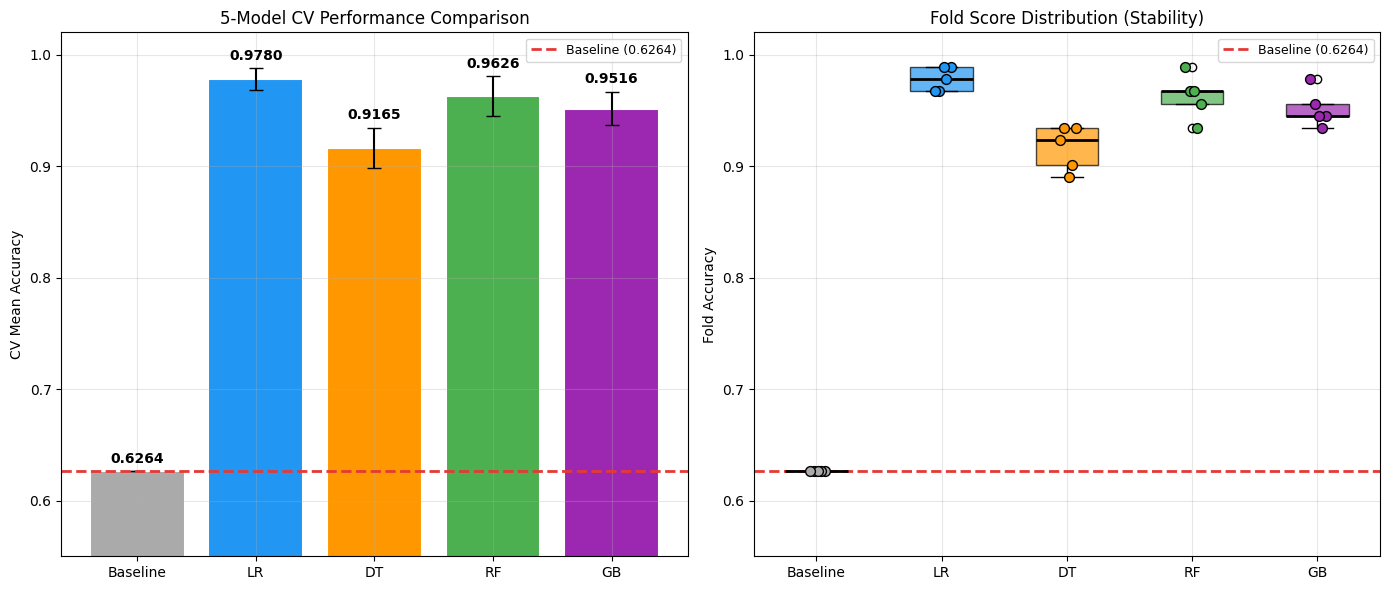

In [17]:
names = list(results.keys())
means = [results[n]["cv_mean"] for n in names]
stds = [results[n]["cv_std"] for n in names]
colors = ["#AAAAAA", "#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: CV 평균 막대그래프
bars = axes[0].bar(names, means, yerr=stds, capsize=5,
                   color=colors, edgecolor="white", linewidth=1.5)
axes[0].axhline(y=baseline_cv, color="#E53935", linestyle="--",
                linewidth=2, label=f"Baseline ({baseline_cv:.4f})")
for bar, m, s in zip(bars, means, stds):
    axes[0].text(bar.get_x() + bar.get_width()/2., m + s + 0.005,
                 f"{m:.4f}", ha="center", va="bottom", fontweight="bold")
axes[0].set_ylabel("CV Mean Accuracy")
axes[0].set_title("5-Model CV Performance Comparison")
axes[0].set_ylim(0.55, 1.02)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# 오른쪽: fold별 박스플롯
box_data = [all_fold_scores[n] for n in names]
bp = axes[1].boxplot(box_data, labels=names, patch_artist=True, widths=0.5,
                     medianprops=dict(color="black", linewidth=2))
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
for i, (name, sc) in enumerate(all_fold_scores.items()):
    jitter = np.random.RandomState(42).uniform(-0.08, 0.08, size=len(sc))
    axes[1].scatter([i+1]*len(sc) + jitter, sc,
                    color=colors[i], edgecolor="black", s=50, zorder=5)
axes[1].axhline(y=baseline_cv, color="#E53935", linestyle="--",
                linewidth=2, label=f"Baseline ({baseline_cv:.4f})")
axes[1].set_ylabel("Fold Accuracy")
axes[1].set_title("Fold Score Distribution (Stability)")
axes[1].set_ylim(0.55, 1.02)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

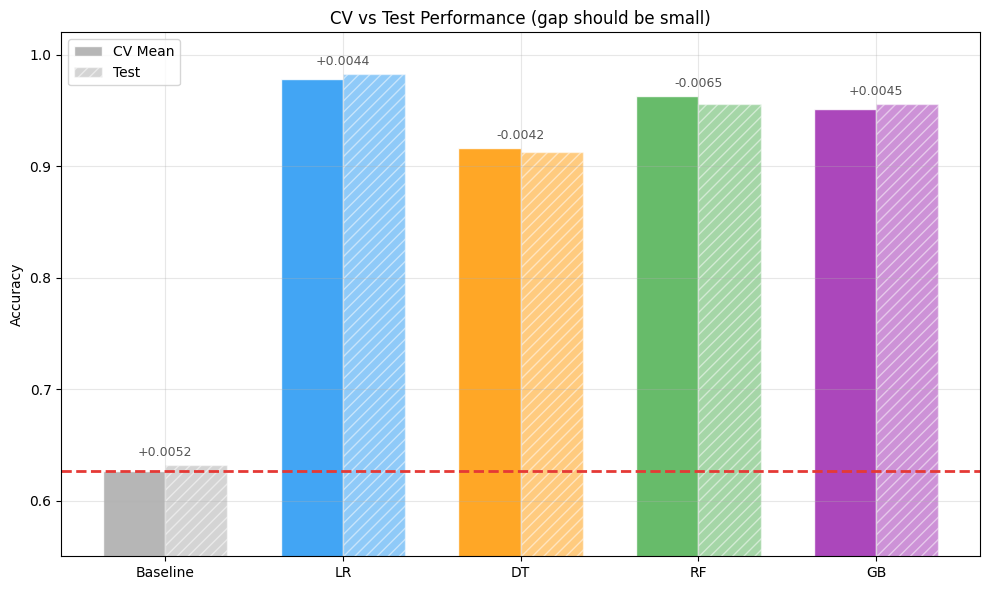

In [18]:
# CV vs 테스트 비교
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(names))
width = 0.35
cv_vals = [results[n]["cv_mean"] for n in names]
test_vals = [results[n]["test"] for n in names]

ax.bar(x_pos - width/2, cv_vals, width, label="CV Mean",
       color=colors, alpha=0.85, edgecolor="white")
ax.bar(x_pos + width/2, test_vals, width, label="Test",
       color=colors, alpha=0.5, edgecolor="white", hatch="///")
ax.axhline(y=baseline_cv, color="#E53935", linestyle="--", linewidth=2)

for i, n in enumerate(names):
    d = results[n]["diff"]
    y_max = max(cv_vals[i], test_vals[i])
    ax.text(i, y_max + 0.008, f"{d:+.4f}", ha="center", fontsize=9, color="#555")

ax.set_xticks(x_pos)
ax.set_xticklabels(names)
ax.set_ylabel("Accuracy")
ax.set_title("CV vs Test Performance (gap should be small)")
ax.set_ylim(0.55, 1.02)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 17. 보너스 — GB + GridSearchCV 튜닝
- GB는 **튜닝 여지가 가장 큰 모델** (Step 15 기준 ❹)
- Pipeline + GridSearchCV로 최적 파라미터 탐색
- 튜닝 전/후 CV 점수 비교

**⚠ 참고**: breast_cancer 데이터에서는 LR이 이미 높기 때문에
GB 튜닝 효과가 제한적일 수 있습니다.
피처가 많거나 비선형 관계가 강한 데이터에서 GB 튜닝의 효과가 더 극적입니다.

In [19]:
pipe_gb_tune = Pipeline([
    ("model", GradientBoostingClassifier(random_state=42)),
])

param_grid_gb = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__max_depth": [3, 5, 7],
}

grid_gb = GridSearchCV(
    pipe_gb_tune, param_grid_gb,
    cv=cv, scoring="accuracy", n_jobs=-1,
)
grid_gb.fit(X_train, y_train)

gb_before = results["GB"]["cv_mean"]
gb_after = grid_gb.best_score_

print("GB + GridSearchCV 튜닝 결과")
print("=" * 55)
print(f"최적 파라미터  : {grid_gb.best_params_}")
print(f"튜닝 전 CV     : {gb_before:.4f}")
print(f"튜닝 후 CV     : {gb_after:.4f}")
print(f"개선폭         : {(gb_after - gb_before)*100:+.2f}%p")
print(f"테스트 점수    : {grid_gb.score(X_test, y_test):.4f}")
print()
print("⚠ 주의: 이 결과는 특정 데이터셋에서의 비교입니다.")
print("  어떤 모델이 무조건 좋은 것은 아닙니다.")
print("  항상 여러 모델을 시도하고 교차검증으로 비교하는 것이 정답입니다.")

GB + GridSearchCV 튜닝 결과
최적 파라미터  : {'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 200}
튜닝 전 CV     : 0.9516
튜닝 후 CV     : 0.9736
개선폭         : +2.20%p
테스트 점수    : 0.9561

⚠ 주의: 이 결과는 특정 데이터셋에서의 비교입니다.
  어떤 모델이 무조건 좋은 것은 아닙니다.
  항상 여러 모델을 시도하고 교차검증으로 비교하는 것이 정답입니다.
